<a href="https://colab.research.google.com/github/BilalKhaliqWillis/BILAL-Assignment2/blob/main/BILAL_Assignment_3_Text_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()

Saving spam.csv to spam.csv


In [2]:
import pandas as pd
import re
from wordcloud import WordCloud
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer

In [3]:
df = pd.read_csv('spam.csv', encoding='latin-1')
df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [4]:
df.info()
df['label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   label   5572 non-null   object
 1   text    5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB


,count
label,
ham,4825
spam,747


In [5]:
def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

df['cleaned_text'] = df['text'].apply(clean_text)

In [6]:
def tokenize_text(text):
    return text.split()

df['tokens'] = df['cleaned_text'].apply(tokenize_text)

In [7]:
from collections import Counter
all_words = ' '.join(df['cleaned_text']).split()
Counter(all_words).most_common(10)

[('to', 2240),
 ('i', 2239),
 ('you', 2124),
 ('a', 1433),
 ('the', 1323),
 ('u', 1143),
 ('and', 970),
 ('in', 887),
 ('is', 886),
 ('me', 786)]

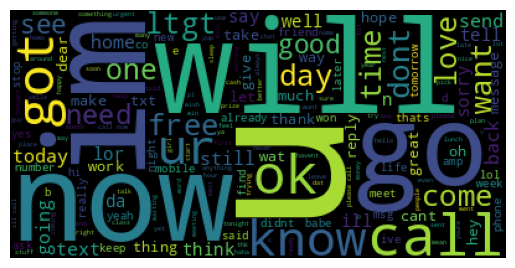

In [8]:
wordcloud = WordCloud().generate(' '.join(df['cleaned_text']))
plt.imshow(wordcloud)
plt.axis('off')
plt.show()

In [9]:
tfidf = TfidfVectorizer(max_features=100)
X = tfidf.fit_transform(df['cleaned_text'])
print(X.shape)

(5572, 100)


In [10]:
df.to_csv('processed_spam.csv', index=False)
files.download('processed_spam.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>